In [120]:
# Cella 1: importazione librerie


import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares
import pandas as pd
import matplotlib.pyplot as plt

# Impostazione dello stile grafico
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

In [156]:
# Cella 2: parametri del modello

# --- PARAMETRI FISICI ---
# Radionuclide di esempio: Lutezio-177 (177Lu)
T_half = 160.8  # Emivita fisica in ore (~6.7 giorni)
lmbda = 0.0     # Impostato a 0 per dati decay-corrected

# --- PARAMETRI CINETICI ---
# Costanti di velocità e parametri di Michaelis-Menten
k0 = 1.0        # Costante di dissociazione/stacco koff (h^-1)
k1 = 0.04       # Costante di associazione kon (h^-1 unit^-1)
Vmax = 12.0     # Velocità massima di internalizzazione (kBq/h) - Michaelis-Menten
Km = 50.0       # Costante di Michaelis per l'internalizzazione (kBq)
k3 = 0.001       # Costante di washout/efflux kout (h^-1)

# --- PARAMETRI DELLA COLTURA ---
Rfree0 = 100.0  # Quantità iniziale di recettori liberi R_free(0)
A0 = 100.0      # Attività iniziale iniettata nel terreno di coltura Am(0) (kBq)

In [161]:
# Cella 3: modello teorico con Michaelis-Menten (no dati)

def cellular_kinetic_system(t, y, lmbda, k0, k1, Vmax, Km, k3):
    """
    Sistema ODE a 5 compartimenti con cinetica di Michaelis-Menten per l'internalizzazione:
    y = [Am, Ab, Rfree, Aint, Adec]
    """
    Am, Ab, Rfree, Aint, Adec = y
    
    # Flusso di internalizzazione saturabile (Michaelis-Menten)
    v_int = (Vmax * Ab) / (Km + Ab) if (Km + Ab) > 1e-12 else 0.0
    
    # Equazioni differenziali del sistema
    dAm_dt    = -lmbda * Am - k1 * Rfree * Am + k0 * Ab
    dAb_dt    =   k1 * Rfree * Am + k3 * Aint - (lmbda + k0) * Ab - v_int
    dRfree_dt = - k1 * Am * Rfree + k0 * Ab - k3 * Aint
    dAint_dt  =   v_int - (lmbda + k3) * Aint
    dAdec_dt  =   lmbda * (Am + Ab + Aint)
    
    return [dAm_dt, dAb_dt, dRfree_dt, dAint_dt, dAdec_dt]

# Condizioni iniziali: Am(0)=A0, Ab(0)=0, Rfree(0)=Rfree0, Aint(0)=0, Adec(0)=0
y0 = [A0, 0.0, Rfree0, 0.0, 0.0]

# Intervallo temporale di simulazione (ore)
t_span = (0, 144)
t_eval = np.linspace(t_span[0], t_span[1], 1000)

# Risoluzione del sistema ODE (metodo RK45)
sol = solve_ivp(
    cellular_kinetic_system, 
    t_span, 
    y0, 
    t_eval=t_eval, 
    args=(lmbda, k0, k1, Vmax, Km, k3),
    method='RK45'
)

# Estrazione dei risultati
t = sol.t
Am, Ab, Rfree, Aint, Adec = sol.y
A_cell_total = Ab + Aint  # Attività totale accumulata dalla cellula (membrana + internalizzata)
A_tot = Am + Ab + Aint + Adec

# Calcolo dell'Attività Cumulata A_tilde (integrale dell'attività nel tempo)
cumulated_activity_cell = np.trapezoid(A_cell_total, t)  # in kBq*h

print("--------------------------------------------------")
print(f"Attività Cumulata Cellulare Integrata (0-{t_span[1]}h): {cumulated_activity_cell:.2f} kBq·h")
print("--------------------------------------------------")

--------------------------------------------------
Attività Cumulata Cellulare Integrata (0-144h): 12796.23 kBq·h
--------------------------------------------------


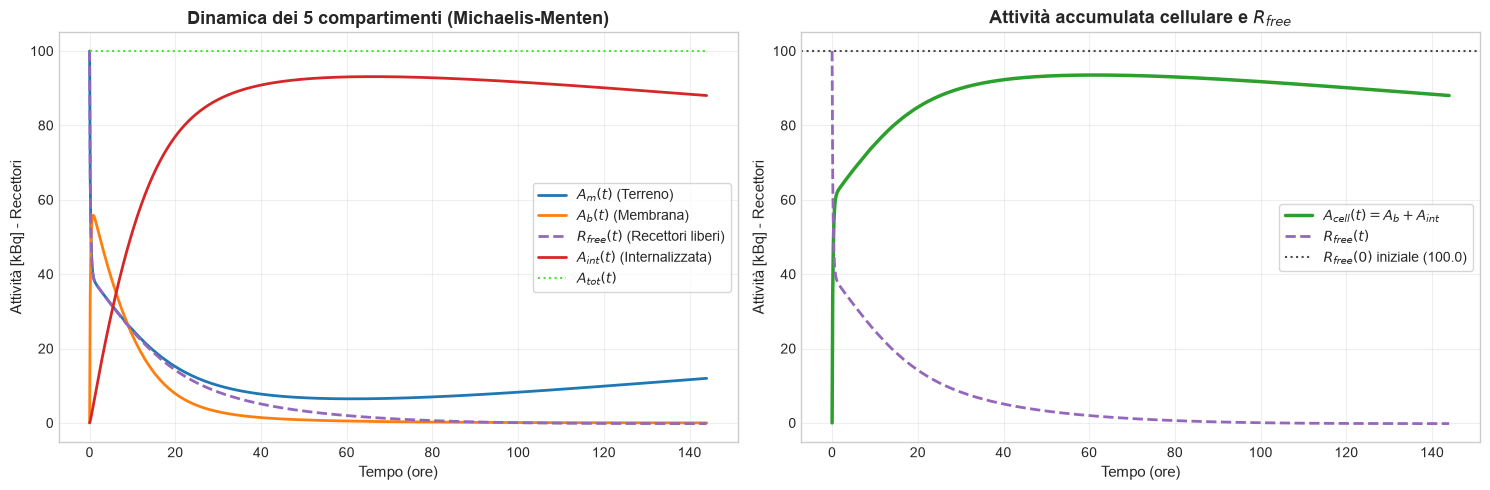

In [162]:
# Cella 4: visualizzazione grafica

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Grafico 1: Cinetica nei compartimenti
axes[0].plot(t, Am, label='$A_m(t)$ (Terreno)', color='#1f77b4', linewidth=2)
axes[0].plot(t, Ab, label='$A_b(t)$ (Membrana)', color='#ff7f0e', linewidth=2)
axes[0].plot(t, Rfree, label='$R_{free}(t)$ (Recettori liberi)', color='#9467bd', linestyle='--', linewidth=2)
axes[0].plot(t, Aint, label='$A_{int}(t)$ (Internalizzata)', color='#d62728', linewidth=2)
axes[0].plot(t, A_tot, label='$A_{tot}(t)$', color="#45e72f", linewidth=1.5, linestyle=':')
axes[0].set_xlabel('Tempo (ore)', fontsize=11)
axes[0].set_ylabel('Attività [kBq] - Recettori', fontsize=11)
axes[0].set_title('Dinamica dei 5 compartimenti (Michaelis-Menten)', fontsize=13, fontweight='bold')
axes[0].legend(frameon=True)
axes[0].grid(True, alpha=0.3)

# Grafico 2: Attività Totale Cellulare e Deplezione Recettori
axes[1].plot(t, A_cell_total, label='$A_{cell}(t) = A_b + A_{int}$', color='#2ca02c', linewidth=2.5)
axes[1].plot(t, Rfree, label='$R_{free}(t)$', color='#9467bd', linewidth=2, linestyle='--')
axes[1].axhline(y=Rfree0, color='black', linestyle=':', alpha=0.7, label=f'$R_{{free}}(0)$ iniziale ({Rfree0})')
axes[1].set_xlabel('Tempo (ore)', fontsize=11)
axes[1].set_ylabel('Attività [kBq] - Recettori', fontsize=11)
axes[1].set_title('Attività accumulata cellulare e $R_{free}$', fontsize=13, fontweight='bold')
axes[1].legend(frameon=True)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

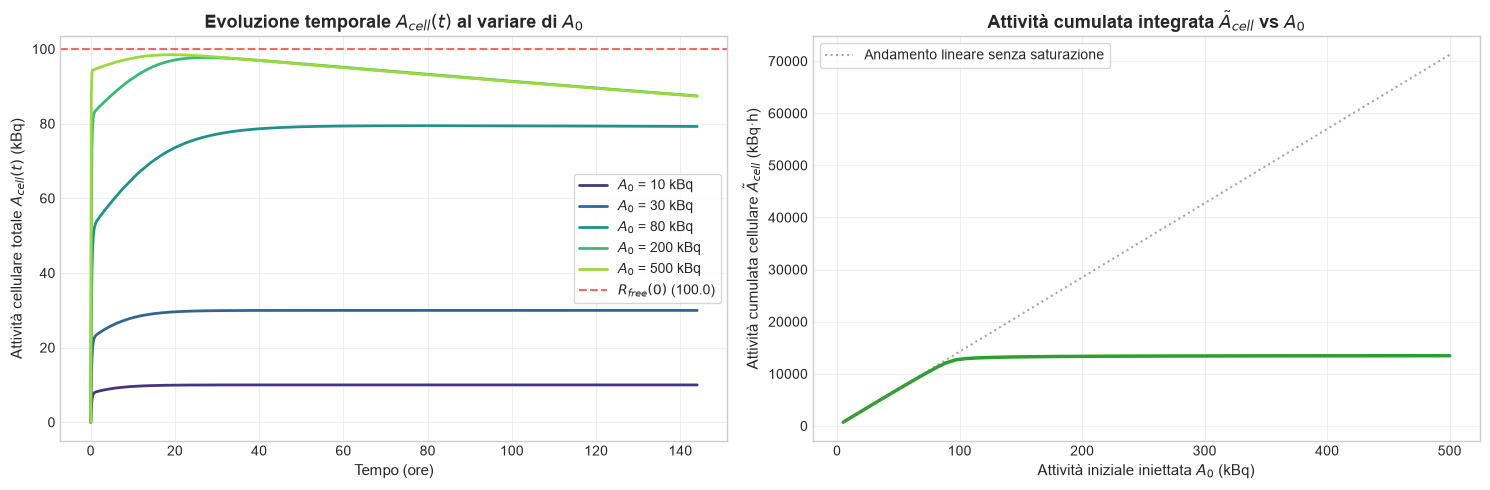

In [163]:
# Cella 5: comportamento in funzione di A0

A0_range = np.linspace(5, 500, 60)  # Variazione di A0 da 5 a 500 kBq

cumulated_A_list = []
max_A_cell_list = []

for A0_i in A0_range:
    y0_i = [A0_i, 0.0, Rfree0, 0.0, 0.0]
    sol_i = solve_ivp(
        cellular_kinetic_system, 
        t_span, 
        y0_i, 
        t_eval=t_eval, 
        args=(lmbda, k0, k1, Vmax, Km, k3),
        method='RK45'
    )
    
    A_cell_i = sol_i.y[1] + sol_i.y[3]  # Ab (y[1]) + Aint (y[3])
    
    max_A_cell_list.append(np.max(A_cell_i))
    cumulated_A_list.append(np.trapezoid(A_cell_i, sol_i.t))

# --- VISUALIZZAZIONE GRAFICA ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Grafico 1: Curve temporali A_cell(t) al variare di A0
A0_samples = [10, 30, 80, 200, 500]
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(A0_samples)))

for A0_sample, color in zip(A0_samples, colors):
    sol_sample = solve_ivp(
        cellular_kinetic_system, 
        t_span, 
        [A0_sample, 0.0, Rfree0, 0.0, 0.0], 
        t_eval=t_eval, 
        args=(lmbda, k0, k1, Vmax, Km, k3),
        method='RK45'
    )
    A_cell_sample = sol_sample.y[1] + sol_sample.y[3]
    axes[0].plot(sol_sample.t, A_cell_sample, label=f'$A_0$ = {A0_sample} kBq', color=color, linewidth=2)

axes[0].axhline(y=Rfree0, color='red', linestyle='--', alpha=0.6, label=f'$R_{{free}}(0)$ ({Rfree0})')
axes[0].set_xlabel('Tempo (ore)', fontsize=11)
axes[0].set_ylabel('Attività cellulare totale $A_{cell}(t)$ (kBq)', fontsize=11)
axes[0].set_title('Evoluzione temporale $A_{cell}(t)$ al variare di $A_0$', fontsize=13, fontweight='bold')
axes[0].legend(frameon=True)
axes[0].grid(True, alpha=0.3)

# Grafico 2: Attività Cumulata vs A0
axes[1].plot(A0_range, cumulated_A_list, color='#2ca02c', linewidth=2.5)
axes[1].set_xlabel('Attività iniziale iniettata $A_0$ (kBq)', fontsize=11)
axes[1].set_ylabel('Attività cumulata cellulare $\\tilde{A}_{cell}$ (kBq·h)', fontsize=11)
axes[1].set_title('Attività cumulata integrata $\\tilde{A}_{cell}$ vs $A_0$', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

linear_trend = cumulated_A_list[0] / A0_range[0] * A0_range
axes[1].plot(A0_range, linear_trend, color='gray', linestyle=':', alpha=0.7, label='Andamento lineare senza saturazione')
axes[1].legend(frameon=True)

plt.tight_layout()
plt.show()

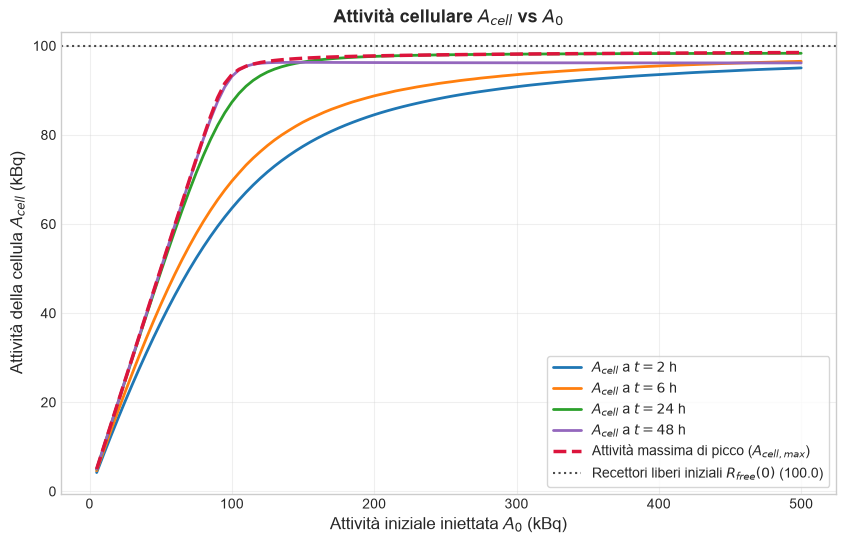

In [164]:
# Cella 6: A_cell vs A_0

A0_range = np.linspace(5, 500, 100)
time_points = [2, 6, 24, 48]

A_cell_at_times = {t_val: [] for t_val in time_points}
A_cell_max = []

for A0_i in A0_range:
    y0_i = [A0_i, 0.0, Rfree0, 0.0, 0.0]
    sol_i = solve_ivp(
        cellular_kinetic_system, 
        t_span, 
        y0_i, 
        t_eval=t_eval, 
        args=(lmbda, k0, k1, Vmax, Km, k3),
        method='RK45'
    )
    
    A_cell_i = sol_i.y[1] + sol_i.y[3]  # Ab (y[1]) + Aint (y[3])
    
    for t_val in time_points:
        idx = np.argmin(np.abs(sol_i.t - t_val))
        A_cell_at_times[t_val].append(A_cell_i[idx])
        
    A_cell_max.append(np.max(A_cell_i))

plt.figure(figsize=(10, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd']

for t_val, color in zip(time_points, colors):
    plt.plot(A0_range, A_cell_at_times[t_val], 
             label=f'$A_{{cell}}$ a $t = {t_val}$ h', 
             color=color, linewidth=2)

plt.plot(A0_range, A_cell_max, 
         label='Attività massima di picco ($A_{cell, max}$)', 
         color='crimson', linestyle='--', linewidth=2.5)

plt.axhline(y=Rfree0, color='black', linestyle=':', alpha=0.7, 
            label=f'Recettori liberi iniziali $R_{{free}}(0)$ ({Rfree0})')

plt.xlabel('Attività iniziale iniettata $A_0$ (kBq)', fontsize=12)
plt.ylabel('Attività della cellula $A_{cell}$ (kBq)', fontsize=12)
plt.title('Attività cellulare $A_{cell}$ vs $A_0$', fontsize=13, fontweight='bold')
plt.legend(frameon=True, fontsize=10)
plt.grid(True, alpha=0.3)

plt.show()

<>:227: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:230: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:227: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:230: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/var/folders/kz/0cx5bgkd1lb9s2rncqvsctcr0000gn/T/ipykernel_27788/804453904.py:227: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  axes[0].axhline(y=2, color='red', linestyle=':', alpha=0.7, label='Banda $\pm 2\sigma$')
/var/folders/kz/0cx5bgkd1lb9s2rncqvsctcr0000gn/T/ipykernel_

 RISULTATI FIT GLOBALE (MICHAELIS-MENTEN PURAMENTE SPECIFICO)
k0 (Dissociazione koff)        : 2.738770e+01 ± 1.526079e+01 h^-1
k1 (Associazione kon)          : 4.790127e-04 ± 8.131325e-04 h^-1 (kBq/mL)^-1
Vmax (Velocità max int.)       : 7.227202e-02 ± 1.178111e-02 (Bq/cell)/h
Km (Saturazione int.)          : 1.000000e-04 ± 1.161171e-03 Bq/cellula
k3 (Efflux/Riciclo kout)       : 6.127120e-01 ± 1.364774e-01 h^-1
R_free,0 (Recettori liberi t=0): 1.246096e+00 ± 2.045371e+00 (adimensionale)
--------------------------------------------------
Punti Sperimentali Totali (N)  : 96
Chi-quadro Totale (Chi2)       : 141.9051
Gradi di libertà (dof)         : 90
Chi-quadro Ridotto             : 1.5767


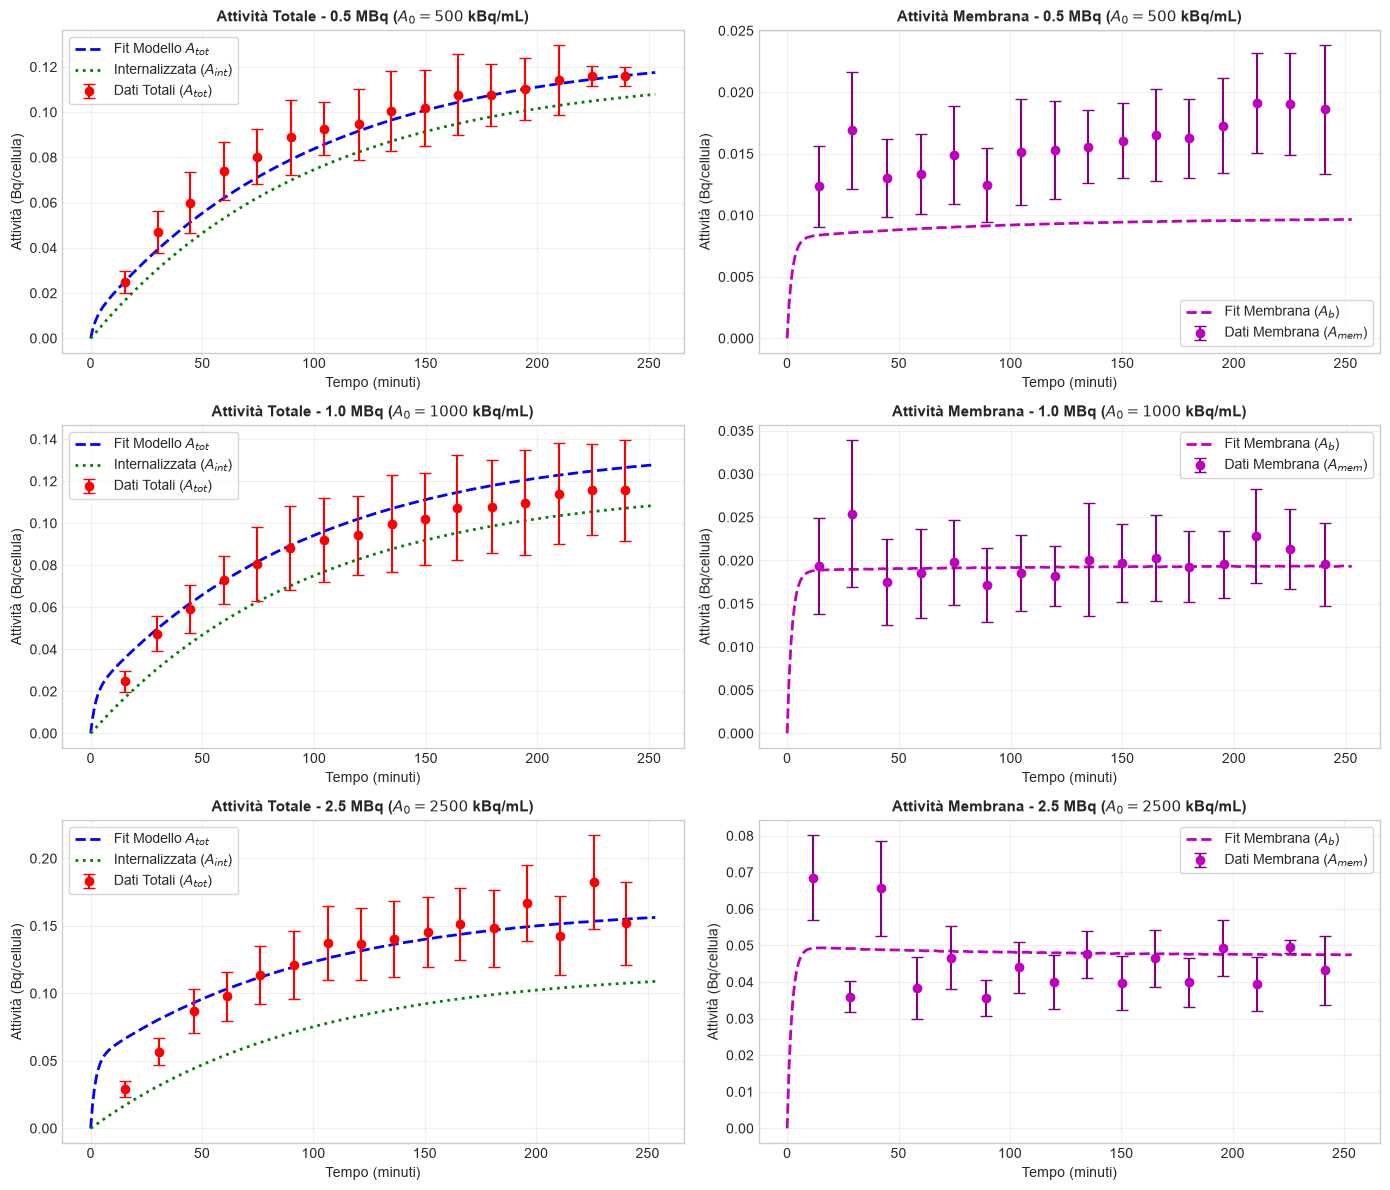

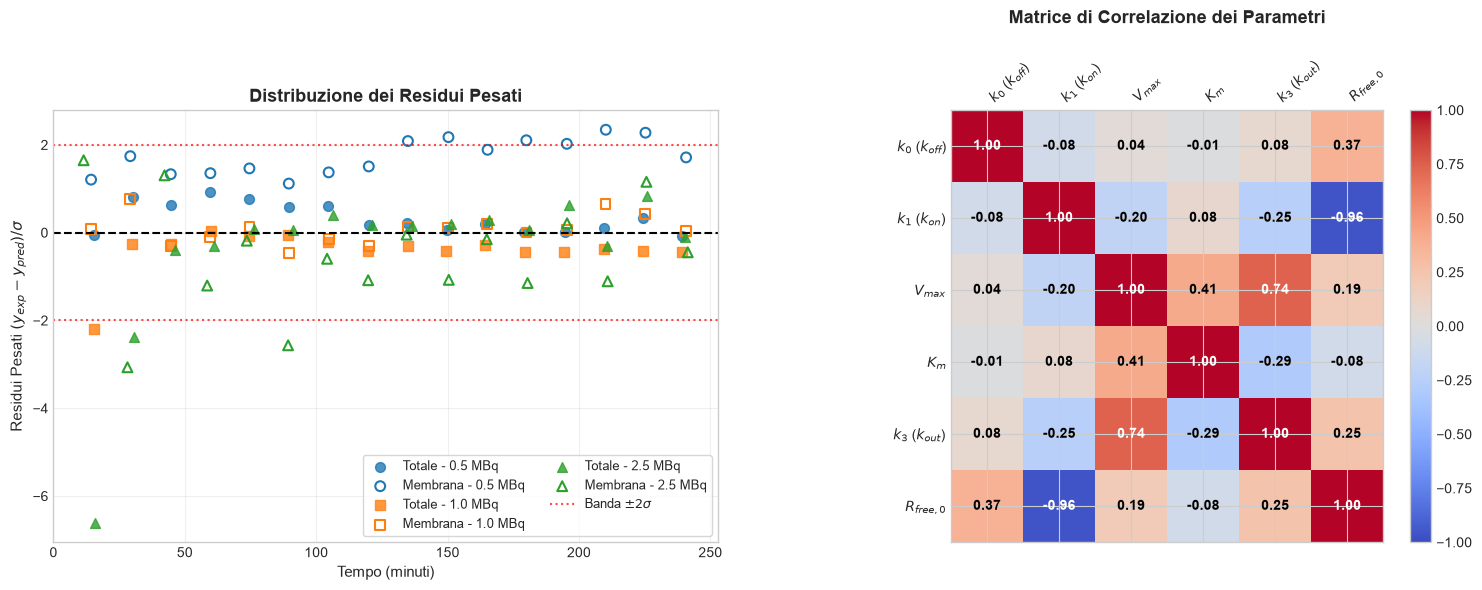

In [166]:
# Cella 7: Fit dati in letteratura che usano Lu-177
# =============================================================================
# 1. CARICAMENTO DEI DATASET MULTI-CONCENTRAZIONE
# =============================================================================
dataset_info = [
    {
        'label': '0.5 MBq',
        'A0': 500.0,
        'tot_val': 'cell_activity_05MBq_values.csv',
        'tot_err': 'cell_activity_05MBq_errors.csv',
        'mem_val': 'membrane_activity_05MBq_values.csv',
        'mem_err': 'membrane_activity_05MBq_errors.csv'
    },
    {
        'label': '1.0 MBq',
        'A0': 1000.0,
        'tot_val': 'cell_activity_1MBq_values.csv',
        'tot_err': 'cell_activity_1MBq_errors.csv',
        'mem_val': 'membrane_activity_1MBq_values.csv',
        'mem_err': 'membrane_activity_1MBq_errors.csv'
    },
    {
        'label': '2.5 MBq',
        'A0': 2500.0,
        'tot_val': 'cell_activity_25MBq_values.csv',
        'tot_err': 'cell_activity_25MBq_errors.csv',
        'mem_val': 'membrane_activity_25MBq_values.csv',
        'mem_err': 'membrane_activity_25MBq_errors.csv'
    }
]

exp_data = []

for ds in dataset_info:
    df_tot_data = pd.read_csv(ds['tot_val'], header=None)
    df_tot_err  = pd.read_csv(ds['tot_err'], header=None)
    t_min_tot   = df_tot_data.iloc[:, 0].values
    y_tot_exp   = df_tot_data.iloc[:, 1].values
    err_tot     = np.maximum(np.abs(df_tot_err.iloc[:, 1].values - y_tot_exp), 1e-8)
    
    df_mem_data = pd.read_csv(ds['mem_val'], header=None)
    df_mem_err  = pd.read_csv(ds['mem_err'], header=None)
    t_min_mem   = df_mem_data.iloc[:, 0].values
    y_mem_exp   = df_mem_data.iloc[:, 1].values
    err_mem     = np.maximum(np.abs(df_mem_err.iloc[:, 1].values - y_mem_exp), 1e-8)
    
    exp_data.append({
        'label': ds['label'],
        'A0': ds['A0'],
        't_min_tot': t_min_tot, 't_exp_tot': t_min_tot / 60.0, 'y_tot_exp': y_tot_exp, 'err_tot': err_tot,
        't_min_mem': t_min_mem, 't_exp_mem': t_min_mem / 60.0, 'y_mem_exp': y_mem_exp, 'err_mem': err_mem
    })

lmbda = 0.0  # Decadimento trascurato per dati decay-corrected

# =============================================================================
# 2. MODELLO ODE CON MICHAELIS-MENTEN (SENZA NSB)
# =============================================================================
def solve_ode_system(params, t_points, A0):
    """
    Risolve il sistema ODE puramente specifico.
    params = [k0, k1, Vmax, Km, k3, Rfree0]
    """
    k0, k1, Vmax, Km, k3, Rfree0 = params

    def ode_system(t, y):
        Am, Ab, Rfree, Aint = y
        
        # Flusso di internalizzazione saturabile tipo Michaelis-Menten
        v_int = (Vmax * Ab) / (Km + Ab) if (Km + Ab) > 1e-12 else 0.0
        
        dAm    = - lmbda * Am - k1 * Rfree * Am + k0 * Ab
        dAb    =   k1 * Rfree * Am + k3 * Aint - k0 * Ab - v_int - lmbda * Ab
        dRfree = - k1 * Am * Rfree + k0 * Ab
        dAint  =   v_int - (k3 + lmbda) * Aint
        return [dAm, dAb, dRfree, dAint]

    t_span = (0, float(np.max(t_points)))
    sol = solve_ivp(ode_system, t_span, [A0, 0.0, Rfree0, 0.0], t_eval=t_points, method='RK45')

    Ab_spec = sol.y[1]
    Aint = sol.y[3]

    A_mem_pred = Ab_spec
    A_tot_pred = Ab_spec + Aint

    return A_mem_pred, A_tot_pred

def global_residuals(params, datasets):
    """Calcola i residui pesati per il fit."""
    all_residuals = []
    for exp in datasets:
        A0 = exp['A0']
        
        pred_mem, pred_tot = solve_ode_system(params, exp['t_exp_tot'], A0)
        res_tot = (pred_tot - exp['y_tot_exp']) / exp['err_tot']
        
        pred_mem, _ = solve_ode_system(params, exp['t_exp_mem'], A0)
        res_mem = (pred_mem - exp['y_mem_exp']) / exp['err_mem']
        
        all_residuals.extend(res_tot)
        all_residuals.extend(res_mem)
        
    return np.array(all_residuals)

# =============================================================================
# 3. FIT GLOBALE ROBUSTO (6 PARAMETRI LIBERI)
# =============================================================================
# Parametri: [k0, k1, Vmax, Km, k3, Rfree0]
p0           = [0.5,  1e-3, 0.1,   0.1,  0.1,  2.0]
lower_bounds = [1e-4, 1e-7, 1e-4,  1e-4, 1e-4, 0.01]
upper_bounds = [50.0, 0.1,  10.0,  10.0, 5.0,  50.0]

res_fit = least_squares(
    global_residuals, 
    p0, 
    bounds=(lower_bounds, upper_bounds),
    args=(exp_data,),
    method='trf',
    loss='soft_l1',   # Loss robusta per gli outlier
    f_scale=1.0
)

# Estrazione parametri fittati
k0_f, k1_f, Vmax_f, Km_f, k3_f, Rfree0_f = res_fit.x
param_names = ['$k_0$ ($k_{off}$)', '$k_1$ ($k_{on}$)', '$V_{max}$', '$K_m$', '$k_3$ ($k_{out}$)', '$R_{free,0}$']

# Statistica del fit
N_tot_points = len(res_fit.fun)
p_num = len(res_fit.x)
dof = N_tot_points - p_num

chi2 = np.sum(res_fit.fun**2)
chi2_red = chi2 / dof if dof > 0 else 1.0

# Matrice di covarianza e correlazione
J = res_fit.jac
cov = np.linalg.pinv(J.T @ J) * chi2_red
param_errors = np.sqrt(np.diagonal(cov))

corr_matrix = np.zeros((p_num, p_num))
for i in range(p_num):
    for j in range(p_num):
        corr_matrix[i, j] = cov[i, j] / (param_errors[i] * param_errors[j])

# =============================================================================
# 4. REPORT DEI RISULTATI
# =============================================================================
print("==================================================")
print(" RISULTATI FIT GLOBALE (MICHAELIS-MENTEN PURAMENTE SPECIFICO)")
print("==================================================")
print(f"k0 (Dissociazione koff)        : {k0_f:.6e} ± {param_errors[0]:.6e} h^-1")
print(f"k1 (Associazione kon)          : {k1_f:.6e} ± {param_errors[1]:.6e} h^-1 (kBq/mL)^-1")
print(f"Vmax (Velocità max int.)       : {Vmax_f:.6e} ± {param_errors[2]:.6e} (Bq/cell)/h")
print(f"Km (Saturazione int.)          : {Km_f:.6e} ± {param_errors[3]:.6e} Bq/cellula")
print(f"k3 (Efflux/Riciclo kout)       : {k3_f:.6e} ± {param_errors[4]:.6e} h^-1")
print(f"R_free,0 (Recettori liberi t=0): {Rfree0_f:.6e} ± {param_errors[5]:.6e} (adimensionale)")
print("--------------------------------------------------")
print(f"Punti Sperimentali Totali (N)  : {N_tot_points}")
print(f"Chi-quadro Totale (Chi2)       : {chi2:.4f}")
print(f"Gradi di libertà (dof)         : {dof}")
print(f"Chi-quadro Ridotto             : {chi2_red:.4f}")
print("==================================================")

# =============================================================================
# 5. GRAFICI DEL FIT PER CIASCUNA CONCENTRAZIONE
# =============================================================================
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

for idx, exp in enumerate(exp_data):
    A0 = exp['A0']
    t_max_eval = max(np.max(exp['t_exp_tot']), np.max(exp['t_exp_mem'])) * 1.05
    t_smooth_h = np.linspace(0, t_max_eval, 300)
    pred_mem_smooth, pred_tot_smooth = solve_ode_system(res_fit.x, t_smooth_h, A0)
    pred_int_smooth = pred_tot_smooth - pred_mem_smooth
    t_smooth_min = t_smooth_h * 60.0

    # Totale
    ax_tot = axes[idx, 0]
    ax_tot.errorbar(exp['t_min_tot'], exp['y_tot_exp'], yerr=exp['err_tot'], 
                    fmt='ro', ecolor='red', capsize=4, label='Dati Totali ($A_{tot}$)', zorder=5)
    ax_tot.plot(t_smooth_min, pred_tot_smooth, 'b--', linewidth=2, label='Fit Modello $A_{tot}$')
    ax_tot.plot(t_smooth_min, pred_int_smooth, 'g:', linewidth=2, label='Internalizzata ($A_{int}$)')
    ax_tot.set_title(f"Attività Totale - {exp['label']} ($A_0 = {A0:.0f}$ kBq/mL)", fontsize=11, fontweight='bold')
    ax_tot.set_xlabel('Tempo (minuti)', fontsize=10)
    ax_tot.set_ylabel('Attività (Bq/cellula)', fontsize=10)
    ax_tot.grid(True, alpha=0.3)
    ax_tot.legend(frameon=True)

    # Membrana
    ax_mem = axes[idx, 1]
    ax_mem.errorbar(exp['t_min_mem'], exp['y_mem_exp'], yerr=exp['err_mem'], 
                    fmt='mo', ecolor='purple', capsize=4, label='Dati Membrana ($A_{mem}$)', zorder=5)
    ax_mem.plot(t_smooth_min, pred_mem_smooth, 'm--', linewidth=2, label='Fit Membrana ($A_b$)')
    ax_mem.set_title(f"Attività Membrana - {exp['label']} ($A_0 = {A0:.0f}$ kBq/mL)", fontsize=11, fontweight='bold')
    ax_mem.set_xlabel('Tempo (minuti)', fontsize=10)
    ax_mem.set_ylabel('Attività (Bq/cellula)', fontsize=10)
    ax_mem.grid(True, alpha=0.3)
    ax_mem.legend(frameon=True)

plt.tight_layout()
plt.show()

# =============================================================================
# 6. GRAFICO DEI RESIDUI PESATI E MATRICE DI CORRELAZIONE
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- GRAFICO A: Residui Pesati vs Tempo ---
markers = ['o', 's', '^']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for idx, exp in enumerate(exp_data):
    A0 = exp['A0']
    pred_mem, pred_tot = solve_ode_system(res_fit.x, exp['t_exp_tot'], A0)
    
    res_tot = (exp['y_tot_exp'] - pred_tot) / exp['err_tot']
    res_mem = (exp['y_mem_exp'] - pred_mem) / exp['err_mem']
    
    axes[0].scatter(exp['t_min_tot'], res_tot, color=colors[idx], marker=markers[idx], 
                    label=f"Totale - {exp['label']}", s=50, alpha=0.8)
    axes[0].scatter(exp['t_min_mem'], res_mem, color=colors[idx], marker=markers[idx], 
                    facecolors='none', edgecolors=colors[idx], linewidth=1.5,
                    label=f"Membrana - {exp['label']}", s=50)

axes[0].axhline(y=0, color='black', linestyle='--', linewidth=1.5)
axes[0].axhline(y=2, color='red', linestyle=':', alpha=0.7, label='Banda $\pm 2\sigma$')
axes[0].axhline(y=-2, color='red', linestyle=':', alpha=0.7)
axes[0].set_xlabel('Tempo (minuti)', fontsize=11)
axes[0].set_ylabel('Residui Pesati $(y_{exp} - y_{pred}) / \sigma$', fontsize=11)
axes[0].set_title('Distribuzione dei Residui Pesati', fontsize=13, fontweight='bold')
axes[0].legend(frameon=True, fontsize=9, ncol=2)
axes[0].grid(True, alpha=0.3)

# --- GRAFICO B: Matrice di Correlazione dei Parametri ---
cax = axes[1].matshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
fig.colorbar(cax, ax=axes[1], fraction=0.046, pad=0.04)

axes[1].set_xticks(range(p_num))
axes[1].set_yticks(range(p_num))
axes[1].set_xticklabels(param_names, rotation=45, ha='left', fontsize=10)
axes[1].set_yticklabels(param_names, fontsize=10)
axes[1].set_title('Matrice di Correlazione dei Parametri', fontsize=13, fontweight='bold', pad=25)

for i in range(p_num):
    for j in range(p_num):
        val = corr_matrix[i, j]
        color = 'white' if abs(val) > 0.6 else 'black'
        axes[1].text(j, i, f"{val:.2f}", ha='center', va='center', color=color, fontweight='bold')

plt.tight_layout()
plt.show()

<>:180: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:183: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:180: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:183: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/var/folders/kz/0cx5bgkd1lb9s2rncqvsctcr0000gn/T/ipykernel_27788/4098687491.py:180: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  axes[0].axhline(y=2, color='red', linestyle=':', alpha=0.7, label='Banda $\pm 2\sigma$')
/var/folders/kz/0cx5bgkd1lb9s2rncqvsctcr0000gn/T/ipykernel

 RISULTATI FIT GLOBALE (DATI NON DECAY-CORRECTED) 
Emivita Radionuclide (T_half)  : 177.60 h (λ = 3.902856e-03 h^-1)
k0 (Dissociazione koff)        : 3.313971e+00 ± 3.091744e+01 h^-1
k1 (Associazione kon)          : 7.632470e-03 ± 8.644495e-05 h^-1 (kBq/mL)^-1
Vmax (Velocità max int.)       : 1.821615e+00 ± 5.247031e+01 (Bq/cell)/h
Km (Saturazione int.)          : 7.112659e+00 ± 2.791680e+02 Bq/cellula
k3 (Efflux/Riciclo kout)       : 1.627985e-01 ± 5.765205e-01 h^-1
R_free,0 (Recettori liberi t=0): 1.135427e+00 ± 6.225153e+00 (adimensionale)
--------------------------------------------------
Punti Sperimentali Totali (N)  : 9
Chi-quadro Totale (Chi2)       : 1.4151
Gradi di libertà (dof)         : 3
Chi-quadro Ridotto             : 0.4717


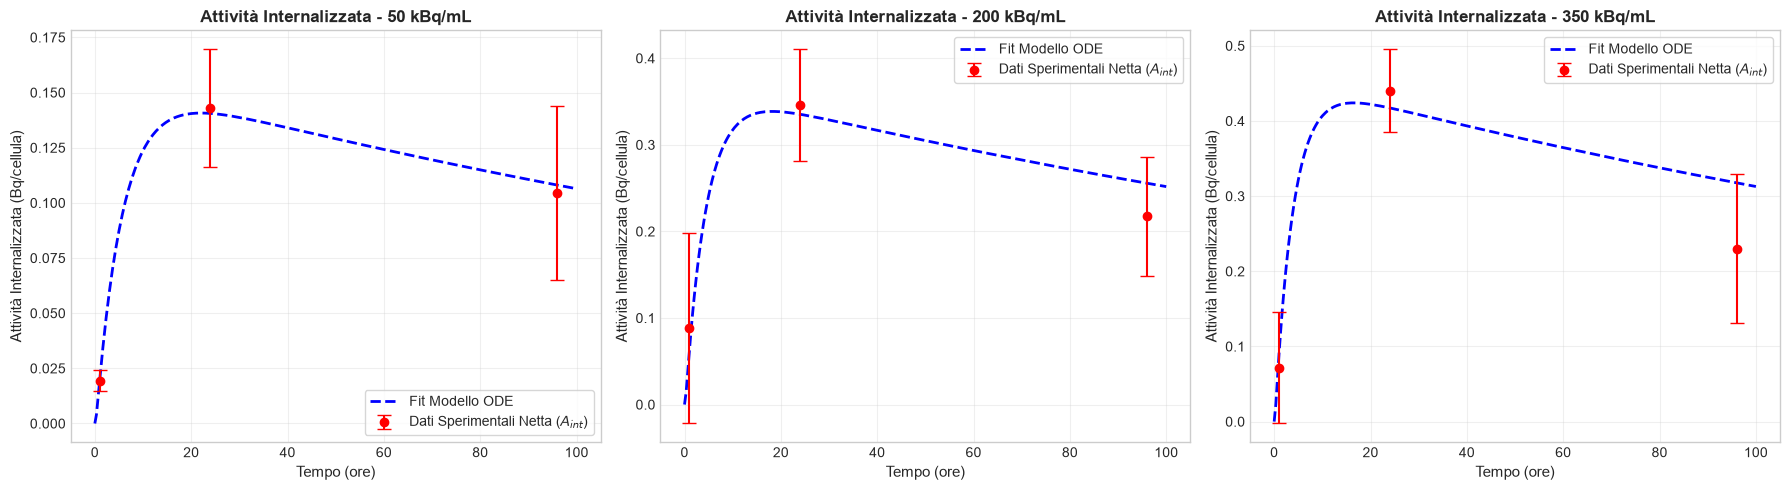

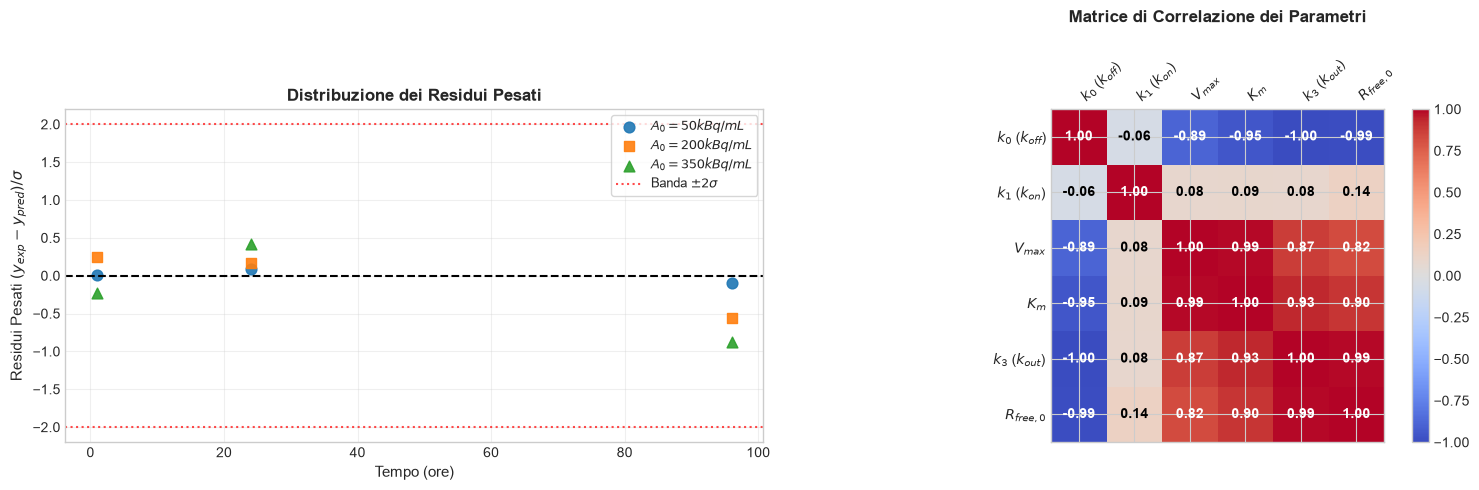

In [ ]:
# Cella 8: fit dati di Pavia con LNCaPs e Ag-111

# =============================================================================
# 1. PARAMETRI FISICI E STRUTTURAZIONE DATI SPERIMENTALI
# =============================================================================
T_half = 7.4 * 24.0            # Emivita fisica del radionuclide in ore (~177.6 h)
lmbda = np.log(2) / T_half     # Costante di decadimento radioattivo (h^-1)

t_exp = np.array([1.0, 24.0, 96.0])       # Tempi di incubazione (ore)
A0_exp = np.array([50.0, 200.0, 350.0])   # Attività iniettate A0 (kBq/mL)
bg = np.array([0.004199309, 0.003368672, 0.000942459]) # Fondo (Bq/cellula)

# Matrice attività cellulare grezza (Bq/cellula) [Righe: A0 | Colonne: t_exp]
A_int_raw = np.array([
    [0.023594163, 0.146368766, 0.105341900],  # A0 = 50 kBq/mL
    [0.092211399, 0.349493079, 0.218233662],  # A0 = 200 kBq/mL
    [0.076153440, 0.443769956, 0.231148121]   # A0 = 350 kBq/mL
])

# Matrice incertezze sperimentali
err_matrix = np.array([
    [0.004641692, 0.026652162, 0.039304734],  # A0 = 50 kBq/mL
    [0.109901502, 0.064321945, 0.068945026],  # A0 = 200 kBq/mL
    [0.074465535, 0.055049521, 0.099395703]   # A0 = 350 kBq/mL
])

# Sottrazione del fondo per colonna (tempo)
A_int_net = np.maximum(A_int_raw - bg, 1e-6)

exp_datasets = []
for idx, A0_val in enumerate(A0_exp):
    exp_datasets.append({
        'label': f'{A0_val:.0f} kBq/mL',
        'A0': A0_val,
        't_exp': t_exp,
        'y_exp': A_int_net[idx, :],
        'err': err_matrix[idx, :]
    })

# =============================================================================
# 2. MODELLO ODE CON DECADIMENTO RADIOATTIVO (lambda > 0) E MICHAELIS-MENTEN
# =============================================================================
def solve_ode_system(params, t_points, A0):
    """
    Risolve il sistema ODE considerando il decadimento radioattivo lambda.
    params = [k0, k1, Vmax, Km, k3, Rfree0]
    """
    k0, k1, Vmax, Km, k3, Rfree0 = params

    def ode_system(t, y):
        Am, Ab, Rfree, Aint = y
        
        # Flusso di internalizzazione saturabile (Michaelis-Menten)
        v_int = (Vmax * Ab) / (Km + Ab) if (Km + Ab) > 1e-12 else 0.0
        
        # Equazioni differenziali con decadimento radioattivo lambda
        dAm    = - lmbda * Am - k1 * Rfree * Am + k0 * Ab
        dAb    =   k1 * Rfree * Am + k3 * Aint - k0 * Ab - v_int - lmbda * Ab
        dRfree = - k1 * Am * Rfree + k0 * Ab
        dAint  =   v_int - (k3 + lmbda) * Aint
        return [dAm, dAb, dRfree, dAint]

    t_span = (0, float(np.max(t_points)))
    sol = solve_ivp(ode_system, t_span, [A0, 0.0, Rfree0, 0.0], t_eval=t_points, method='RK45')

    Aint_pred = sol.y[3]  # Attività internalizzata predetta
    return Aint_pred

def global_residuals(params, datasets):
    """Calcola i residui pesati per il fit globale."""
    all_residuals = []
    for exp in datasets:
        A0 = exp['A0']
        pred_int = solve_ode_system(params, exp['t_exp'], A0)
        res = (pred_int - exp['y_exp']) / exp['err']
        all_residuals.extend(res)
    return np.array(all_residuals)

# =============================================================================
# 3. FIT GLOBALE MULTI-CONCENTRAZIONE
# =============================================================================
# Parametri: [k0, k1, Vmax, Km, k3, Rfree0]
p0           = [0.1,  1e-3,  0.05,  0.1,  0.01, 1.0]
lower_bounds = [0.0,  1e-6,  1e-4,  1e-4, 0.0,  1e-3]
upper_bounds = [10.0, 1.0,   10.0,  50.0, 1.0,  100.0]

res_fit = least_squares(
    global_residuals, 
    p0, 
    bounds=(lower_bounds, upper_bounds),
    args=(exp_datasets,),
    method='trf',
    loss='soft_l1',   # Loss robusta contro gli outlier
    f_scale=1.0
)

# Estrazione parametri fittati
k0_f, k1_f, Vmax_f, Km_f, k3_f, Rfree0_f = res_fit.x
param_names = ['$k_0$ ($k_{off}$)', '$k_1$ ($k_{on}$)', '$V_{max}$', '$K_m$', '$k_3$ ($k_{out}$)', '$R_{free,0}$']

# Statistica del fit
N_tot_points = len(res_fit.fun)
p_num = len(res_fit.x)
dof = N_tot_points - p_num

chi2 = np.sum(res_fit.fun**2)
chi2_red = chi2 / dof if dof > 0 else 1.0

# Matrice di covarianza e correlazione
J = res_fit.jac
cov = np.linalg.pinv(J.T @ J) * chi2_red
param_errors = np.sqrt(np.diagonal(cov))

corr_matrix = np.zeros((p_num, p_num))
for i in range(p_num):
    for j in range(p_num):
        corr_matrix[i, j] = cov[i, j] / (param_errors[i] * param_errors[j])

# =============================================================================
# 4. REPORT DEI RISULTATI
# =============================================================================
print("==================================================")
print(" RISULTATI FIT GLOBALE (DATI NON DECAY-CORRECTED) ")
print("==================================================")
print(f"Emivita Radionuclide (T_half)  : {T_half:.2f} h (λ = {lmbda:.6e} h^-1)")
print(f"k0 (Dissociazione koff)        : {k0_f:.6e} ± {param_errors[0]:.6e} h^-1")
print(f"k1 (Associazione kon)          : {k1_f:.6e} ± {param_errors[1]:.6e} h^-1 (kBq/mL)^-1")
print(f"Vmax (Velocità max int.)       : {Vmax_f:.6e} ± {param_errors[2]:.6e} (Bq/cell)/h")
print(f"Km (Saturazione int.)          : {Km_f:.6e} ± {param_errors[3]:.6e} Bq/cellula")
print(f"k3 (Efflux/Riciclo kout)       : {k3_f:.6e} ± {param_errors[4]:.6e} h^-1")
print(f"R_free,0 (Recettori liberi t=0): {Rfree0_f:.6e} ± {param_errors[5]:.6e} (adimensionale)")
print("--------------------------------------------------")
print(f"Punti Sperimentali Totali (N)  : {N_tot_points}")
print(f"Chi-quadro Totale (Chi2)       : {chi2:.4f}")
print(f"Gradi di libertà (dof)         : {dof}")
print(f"Chi-quadro Ridotto             : {chi2_red:.4f}")
print("==================================================")

# =============================================================================
# 5. GRAFICI DEL FIT PER CIASCUNA CONCENTRAZIONE
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, exp in enumerate(exp_datasets):
    A0 = exp['A0']
    t_smooth_h = np.linspace(0, 100, 300)
    pred_int_smooth = solve_ode_system(res_fit.x, t_smooth_h, A0)

    ax = axes[idx]
    ax.errorbar(exp['t_exp'], exp['y_exp'], yerr=exp['err'], 
                fmt='ro', ecolor='red', capsize=5, elinewidth=1.5, 
                label='Dati Sperimentali Netta ($A_{int}$)', zorder=5)
    ax.plot(t_smooth_h, pred_int_smooth, 'b--', linewidth=2, label='Fit Modello ODE')
    
    ax.set_title(f"Attività Internalizzata - {exp['label']}", fontsize=12, fontweight='bold')
    ax.set_xlabel('Tempo (ore)', fontsize=11)
    ax.set_ylabel('Attività Internalizzata (Bq/cellula)', fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.legend(frameon=True)

plt.tight_layout()
plt.show()

# =============================================================================
# 6. RESIDUI PESATI E MATRICE DI CORRELAZIONE
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Grafico A: Residui Pesati
markers = ['o', 's', '^']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for idx, exp in enumerate(exp_datasets):
    A0 = exp['A0']
    pred_int = solve_ode_system(res_fit.x, exp['t_exp'], A0)
    res = (exp['y_exp'] - pred_int) / exp['err']
    
    axes[0].scatter(exp['t_exp'], res, color=colors[idx], marker=markers[idx], 
                    label=f"$A_0 = {exp['label']}$", s=60, alpha=0.9)

axes[0].axhline(y=0, color='black', linestyle='--', linewidth=1.5)
axes[0].axhline(y=2, color='red', linestyle=':', alpha=0.7, label='Banda $\pm 2\sigma$')
axes[0].axhline(y=-2, color='red', linestyle=':', alpha=0.7)
axes[0].set_xlabel('Tempo (ore)', fontsize=11)
axes[0].set_ylabel('Residui Pesati $(y_{exp} - y_{pred}) / \sigma$', fontsize=11)
axes[0].set_title('Distribuzione dei Residui Pesati', fontsize=12, fontweight='bold')
axes[0].legend(frameon=True, fontsize=9)
axes[0].grid(True, alpha=0.3)

# Grafico B: Matrice di Correlazione dei Parametri
cax = axes[1].matshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
fig.colorbar(cax, ax=axes[1], fraction=0.046, pad=0.04)

axes[1].set_xticks(range(p_num))
axes[1].set_yticks(range(p_num))
axes[1].set_xticklabels(param_names, rotation=45, ha='left', fontsize=10)
axes[1].set_yticklabels(param_names, fontsize=10)
axes[1].set_title('Matrice di Correlazione dei Parametri', fontsize=12, fontweight='bold', pad=25)

for i in range(p_num):
    for j in range(p_num):
        val = corr_matrix[i, j]
        color = 'white' if abs(val) > 0.6 else 'black'
        axes[1].text(j, i, f"{val:.2f}", ha='center', va='center', color=color, fontweight='bold')

plt.tight_layout()
plt.show()

       RISULTATI FIT INDIPENDENTE SUI 3 TEMPI (A0 = 50 kBq Iodio-131)           

--- LINEA CELLULARE: MCF-10 ---
  kin  (Tasso d'ingresso)  : 5.094100e-08 ± 1.426978e-08 h^-1
  kout (Tasso d'uscita)    : 3.285702e+00 ± 2.129760e-16 h^-1
  Chi-quadro Totale (Chi2) : 1.2609
  Gradi di Libertà (dof)   : 1
  Chi-quadro Ridotto       : 1.2609

--- LINEA CELLULARE: MDA ---
  kin  (Tasso d'ingresso)  : 2.648413e-08 ± 8.093997e-09 h^-1
  kout (Tasso d'uscita)    : 2.869312e+00 ± 7.075768e-17 h^-1
  Chi-quadro Totale (Chi2) : 1.5175
  Gradi di Libertà (dof)   : 1
  Chi-quadro Ridotto       : 1.5175


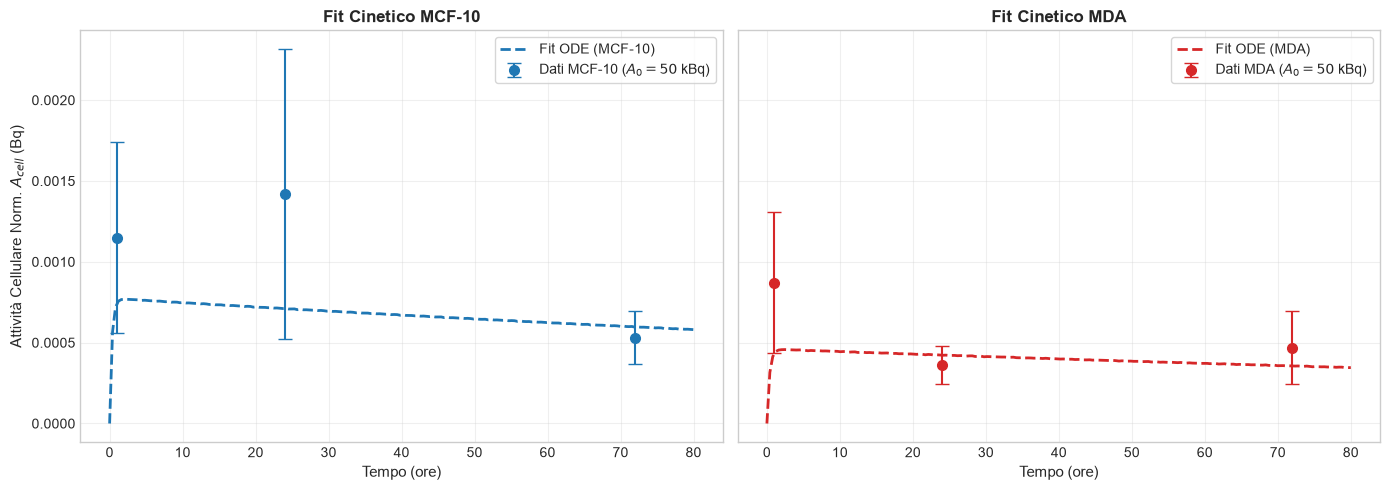

In [167]:
# Cella: Fit indipendente a 3 punti temporali (A0 = 50 kBq I-131) per MCF-10 e MDA

# =============================================================================
# 1. PARAMETRI FISICI IODIO-131 (131I) E CONDIZIONI INIZIALI
# =============================================================================
T_half = 8.02 * 24.0           # Emivita fisica Iodio-131 in ore (192.48 h)
lmbda = np.log(2) / T_half     # Costante di decadimento radioattivo (h^-1)
A0_val = 50000.0               # Attività iniettata A0 = 50 kBq = 50,000 Bq

# =============================================================================
# 2. DATI SPERIMENTALI PER I TRE TEMPI (1h, 24h, 72h)
# =============================================================================
t_exp = np.array([1.0, 24.0, 72.0])  # Ore

datasets = {
    'MCF-10': {
        't_exp': t_exp,
        'y_exp': np.array([1.15e-03, 1.42e-03, 5.31e-04]),  # Attività cellulare (Bq)
        'err':   np.array([5.90e-04, 8.95e-04, 1.62e-04])   # Errore (Bq)
    },
    'MDA': {
        't_exp': t_exp,
        'y_exp': np.array([8.71e-04, 3.62e-04, 4.69e-04]),  # Attività cellulare (Bq)
        'err':   np.array([4.34e-04, 1.19e-04, 2.26e-04])   # Errore (Bq)
    }
}

# =============================================================================
# 3. MODELLO ODE E FUNZIONE RESIDUI PESATI
# =============================================================================
def solve_kinetic_model(params, t_points, A0):
    """
    Risolve il sistema ODE cinetico a due compartimenti:
    - Am: Attività nel terreno
    - Acell: Attività totale accumulata dalla cellula
    params = [kin, kout]
    """
    kin, kout = params

    def ode_system(t, y):
        Am, Acell = y
        dAm    = - lmbda * Am + kout * Acell
        dAcell = kin * Am - (kout + lmbda) * Acell
        return [dAm, dAcell]

    t_span = (0, float(np.max(t_points)))
    sol = solve_ivp(ode_system, t_span, [A0, 0.0], t_eval=t_points, method='RK45')
    return sol.y[1]

def calculate_residuals(params, dataset):
    pred = solve_kinetic_model(params, dataset['t_exp'], A0_val)
    return (pred - dataset['y_exp']) / dataset['err']

# =============================================================================
# 4. ESECUZIONE FIT SEPARATI E CALCOLO INCERTEZZE
# =============================================================================
# Stima iniziale e limiti per [kin, kout]
p0 = [1e-7, 0.05]
bounds = ([0.0, 0.0], [1e-3, 5.0])

fit_results = {}

print("================================================================================")
print("       RISULTATI FIT INDIPENDENTE SUI 3 TEMPI (A0 = 50 kBq Iodio-131)           ")
print("================================================================================")

for cell_line, data in datasets.items():
    res_fit = least_squares(
        calculate_residuals, 
        p0, 
        bounds=bounds, 
        args=(data,),
        method='trf'
    )
    
    kin_f, kout_f = res_fit.x
    
    # Calcolo incertezze da Matrice di Covarianza
    N_tot = len(data['y_exp'])
    p_num = len(res_fit.x)
    dof = N_tot - p_num  # dof = 3 - 2 = 1
    
    chi2 = np.sum(res_fit.fun**2)
    chi2_red = chi2 / dof if dof > 0 else chi2
    
    J = res_fit.jac
    cov = np.linalg.pinv(J.T @ J) * chi2_red
    param_errors = np.sqrt(np.diagonal(cov))
    
    fit_results[cell_line] = {
        'kin': kin_f, 'kin_err': param_errors[0],
        'kout': kout_f, 'kout_err': param_errors[1],
        'chi2': chi2,
        'chi2_red': chi2_red,
        'dof': dof,
        'fit_obj': res_fit
    }
    
    print(f"\n--- LINEA CELLULARE: {cell_line} ---")
    print(f"  kin  (Tasso d'ingresso)  : {kin_f:.6e} ± {param_errors[0]:.6e} h^-1")
    print(f"  kout (Tasso d'uscita)    : {kout_f:.6e} ± {param_errors[1]:.6e} h^-1")
    print(f"  Chi-quadro Totale (Chi2) : {chi2:.4f}")
    print(f"  Gradi di Libertà (dof)   : {dof}")
    print(f"  Chi-quadro Ridotto       : {chi2_red:.4f}")

# =============================================================================
# 5. GRAFICI DEI FIT COMPARATIVI
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

colors = {'MCF-10': '#1f77b4', 'MDA': '#d62728'}
t_smooth = np.linspace(0, 80, 200)

for idx, (cell_line, data) in enumerate(datasets.items()):
    ax = axes[idx]
    color = colors[cell_line]
    res = fit_results[cell_line]
    
    # Simulazione della curva continua fittata
    pred_smooth = solve_kinetic_model([res['kin'], res['kout']], t_smooth, A0_val)
    
    # Grafico punti sperimentali con barre d'errore
    ax.errorbar(data['t_exp'], data['y_exp'], yerr=data['err'], 
                fmt='o', color=color, ecolor=color, capsize=5, elinewidth=1.5,
                markersize=7, label=f"Dati {cell_line} ($A_0 = 50$ kBq)", zorder=5)
    
    # Grafico curva del modello ODE
    ax.plot(t_smooth, pred_smooth, '--', color=color, linewidth=2, 
            label=f"Fit ODE ({cell_line})")
    
    ax.set_title(f"Fit Cinetico {cell_line}", fontsize=12, fontweight='bold')
    ax.set_xlabel('Tempo (ore)', fontsize=11)
    if idx == 0:
        ax.set_ylabel('Attività Cellulare Norm. $A_{cell}$ (Bq)', fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.legend(frameon=True, fontsize=10)

plt.tight_layout()
plt.show()

             RISULTATI FIT SINGOLI PER OGNI CONCENTRAZIONE A0 (131I)             

--- LINEA CELLULARE: MCF-10 ---
  A0 =  25 kBq  -->  kin = 5.144042e-08 h^-1,  kout = 6.602794e-02 h^-1  (Chi2 = 0.0000)
  A0 =  50 kBq  -->  kin = 1.664985e-07 h^-1,  kout = 4.988152e+00 h^-1  (Chi2 = 1.6548)
  A0 =  75 kBq  -->  kin = 5.758937e-07 h^-1,  kout = 8.896963e-01 h^-1  (Chi2 = 0.0000)
  A0 = 100 kBq  -->  kin = 6.395198e-08 h^-1,  kout = 3.369653e-01 h^-1  (Chi2 = 0.0000)

--- LINEA CELLULARE: MDA ---
  A0 =  25 kBq  -->  kin = 2.874075e-08 h^-1,  kout = 1.165184e-01 h^-1  (Chi2 = 0.0000)
  A0 =  50 kBq  -->  kin = 1.125435e-07 h^-1,  kout = 4.462672e+00 h^-1  (Chi2 = 4.9657)
  A0 =  75 kBq  -->  kin = 4.368185e-08 h^-1,  kout = 1.437445e+00 h^-1  (Chi2 = 0.0000)
  A0 = 100 kBq  -->  kin = 1.586587e-07 h^-1,  kout = 5.000000e+00 h^-1  (Chi2 = 1.7146)


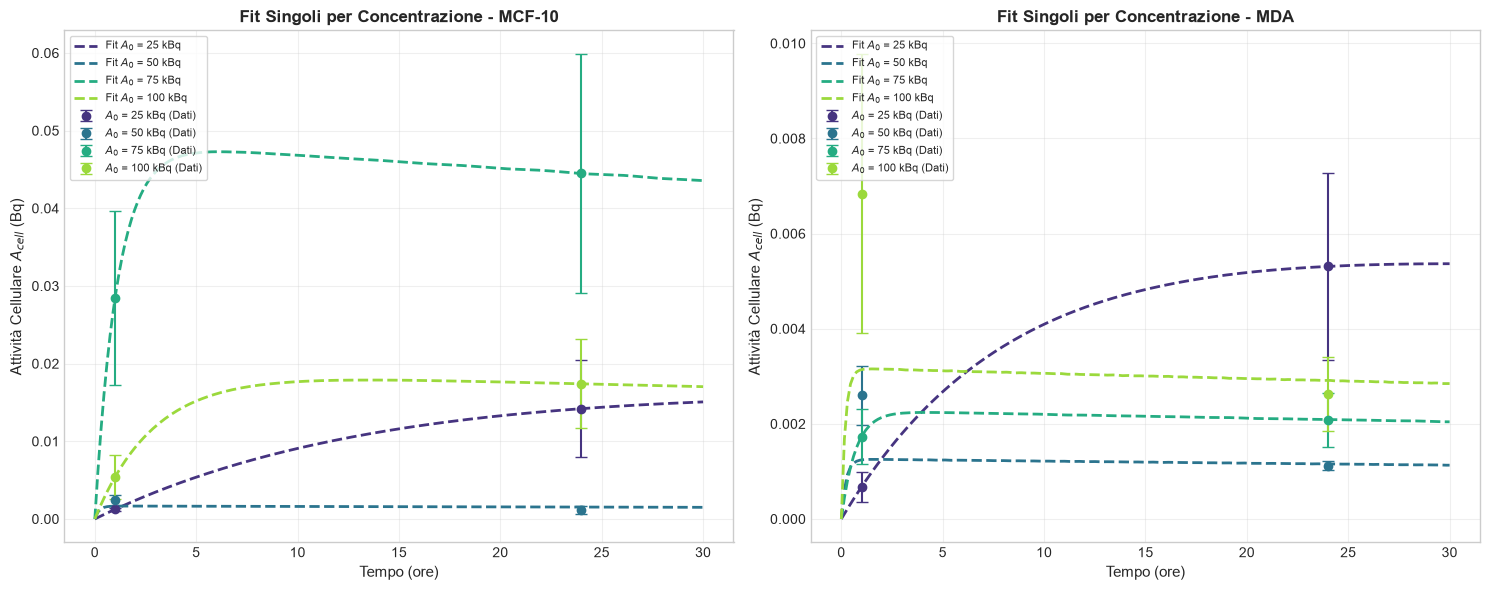


TABELLA RIASSUNTIVA PARAMETRI FITTATI PER SINGOLA CONCENTRAZIONE:
Cell Line  A0 (Bq)   kin (h^-1)  kout (h^-1)         Chi2
   MCF-10  25000.0 5.144042e-08     0.066028 7.808319e-19
   MCF-10  50000.0 1.664985e-07     4.988152 1.654797e+00
   MCF-10  75000.0 5.758937e-07     0.889696 4.680113e-21
   MCF-10 100000.0 6.395198e-08     0.336965 6.693626e-30
      MDA  25000.0 2.874075e-08     0.116518 2.754021e-26
      MDA  50000.0 1.125435e-07     4.462672 4.965700e+00
      MDA  75000.0 4.368185e-08     1.437445 2.765883e-24
      MDA 100000.0 1.586587e-07     5.000000 1.714584e+00


In [168]:
# Cella: Fit Singolo (Per Singola Concentrazione A0) per MCF-10 e MDA (Iodio-131)
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares
import matplotlib.pyplot as plt

# =============================================================================
# 1. PARAMETRI FISICI IODIO-131 (131I)
# =============================================================================
T_half = 8.02 * 24.0           # Emivita Iodio-131 in ore (8.02 giorni = 192.48 h)
lmbda = np.log(2) / T_half     # Costante di decadimento radioattivo (h^-1)

# =============================================================================
# 2. STRUCTURAZIONE DATI SPERIMENTALI
# =============================================================================
bg_mcf10 = {1.0: 0.0, 24.0: 0.0}
bg_mda   = {1.0: 6.82e-05, 24.0: 0.0}

data_mcf10 = [
    {'A0': 25000.0,  't_exp': np.array([1.0, 24.0]), 'y_exp': np.array([1.24e-03, 1.42e-02]) - bg_mcf10[1.0], 'err': np.array([2.03e-04, 6.24e-03])},
    {'A0': 50000.0,  't_exp': np.array([1.0, 24.0]), 'y_exp': np.array([2.41e-03, 1.16e-03]) - bg_mcf10[1.0], 'err': np.array([7.28e-04, 4.88e-04])},
    {'A0': 75000.0,  't_exp': np.array([1.0, 24.0]), 'y_exp': np.array([2.85e-02, 4.45e-02]) - bg_mcf10[1.0], 'err': np.array([1.12e-02, 1.54e-02])},
    {'A0': 100000.0, 't_exp': np.array([1.0, 24.0]), 'y_exp': np.array([5.41e-03, 1.74e-02]) - bg_mcf10[1.0], 'err': np.array([2.86e-03, 5.73e-03])},
]

data_mda = [
    {'A0': 25000.0,  't_exp': np.array([1.0, 24.0]), 'y_exp': np.array([7.44e-04 - bg_mda[1.0], 5.31e-03]), 'err': np.array([3.19e-04, 1.96e-03])},
    {'A0': 50000.0,  't_exp': np.array([1.0, 24.0]), 'y_exp': np.array([2.67e-03 - bg_mda[1.0], 1.12e-03]), 'err': np.array([6.18e-04, 9.38e-05])},
    {'A0': 75000.0,  't_exp': np.array([1.0, 24.0]), 'y_exp': np.array([1.80e-03 - bg_mda[1.0], 2.09e-03]), 'err': np.array([5.84e-04, 5.67e-04])},
    {'A0': 100000.0, 't_exp': np.array([1.0, 24.0]), 'y_exp': np.array([6.91e-03 - bg_mda[1.0], 2.63e-03]), 'err': np.array([2.94e-03, 7.78e-04])},
]

# Protezione da valori <= 0
for ds in data_mcf10 + data_mda:
    ds['y_exp'] = np.maximum(ds['y_exp'], 1e-8)

cell_lines_data = {
    'MCF-10': data_mcf10,
    'MDA': data_mda
}

# =============================================================================
# 3. MODELLO ODE PER SINGOLA CURVA A0 (2 PARAMETRI: kin, kout)
# =============================================================================
def solve_single_curve(params, t_points, A0):
    """
    Risolve il sistema ODE per una singola concentrazione A0.
    params = [kin, kout]
    """
    kin, kout = params

    def ode_system(t, y):
        Am, Acell = y
        dAm    = - lmbda * Am + kout * Acell
        dAcell = kin * Am - (kout + lmbda) * Acell
        return [dAm, dAcell]

    t_span = (0, float(np.max(t_points)))
    sol = solve_ivp(ode_system, t_span, [A0, 0.0], t_eval=t_points, method='RK45')

    return sol.y[1]  # Attività cellulare A_cell(t)

def single_residuals(params, exp_dataset):
    pred_cell = solve_single_curve(params, exp_dataset['t_exp'], exp_dataset['A0'])
    return (pred_cell - exp_dataset['y_exp']) / exp_dataset['err']

# =============================================================================
# 4. ESECUZIONE FIT INDIVIDUALE PER OGNI CONCENTRAZIONE A0
# =============================================================================
# Stima iniziale e limiti per [kin, kout]
p0 = [1e-7, 0.05]
bounds = ([0.0, 0.0], [1e-3, 5.0])

results_summary = []

print("================================================================================")
print("             RISULTATI FIT SINGOLI PER OGNI CONCENTRAZIONE A0 (131I)             ")
print("================================================================================")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for idx, (cell_line, datasets) in enumerate(cell_lines_data.items()):
    ax = axes[idx]
    colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(datasets)))
    t_smooth = np.linspace(0, 30, 200)
    
    print(f"\n--- LINEA CELLULARE: {cell_line} ---")
    
    for exp, color in zip(datasets, colors):
        A0_val = exp['A0']
        
        # Fit dedicato sulla singola concentrazione
        res_fit = least_squares(
            single_residuals, 
            p0, 
            bounds=bounds, 
            args=(exp,),
            method='trf'
        )
        
        kin_f, kout_f = res_fit.x
        chi2 = np.sum(res_fit.fun**2)
        
        results_summary.append({
            'Cell Line': cell_line,
            'A0 (Bq)': A0_val,
            'kin (h^-1)': kin_f,
            'kout (h^-1)': kout_f,
            'Chi2': chi2
        })
        
        print(f"  A0 = {A0_val/1000:3.0f} kBq  -->  kin = {kin_f:.6e} h^-1,  kout = {kout_f:.6e} h^-1  (Chi2 = {chi2:.4f})")
        
        # Generazione curva fittata per il grafico
        pred_smooth = solve_single_curve([kin_f, kout_f], t_smooth, A0_val)
        
        ax.errorbar(exp['t_exp'], exp['y_exp'], yerr=exp['err'], 
                    fmt='o', color=color, ecolor=color, capsize=4, 
                    label=f"$A_0$ = {A0_val/1000:.0f} kBq (Dati)")
        ax.plot(t_smooth, pred_smooth, '--', color=color, linewidth=2, 
                label=f"Fit $A_0$ = {A0_val/1000:.0f} kBq")
        
    ax.set_title(f"Fit Singoli per Concentrazione - {cell_line}", fontsize=12, fontweight='bold')
    ax.set_xlabel('Tempo (ore)', fontsize=11)
    ax.set_ylabel('Attività Cellulare $A_{cell}$ (Bq)', fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.legend(frameon=True, fontsize=8, loc='upper left')

plt.tight_layout()
plt.show()

# Conversione dei risultati in Tabella DataFrame
df_res = pd.DataFrame(results_summary)
print("\n================================================================================")
print("TABELLA RIASSUNTIVA PARAMETRI FITTATI PER SINGOLA CONCENTRAZIONE:")
print("================================================================================")
print(df_res.to_string(index=False))